from SSVEPAnalysisToolbox.datasets import BenchmarkDataset
dataset = BenchmarkDataset(path = '2016_Tsinghua_SSVEP_database')

In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy import signal
from scipy.signal import butter, sosfilt, sosfreqz
from scipy.linalg import eigh

In [ ]:
mat = scipy.io.loadmat('/content/sample_data/S2.mat')
tr_cnt = np.array(mat.get('data'))

tr_Label = np.array(range(40))
tr_Label = np.tile(tr_Label, reps=6)

In [ ]:
print(tr_cnt.shape)
print(tr_Label.shape)

(64, 1500, 40, 6)
(240,)


In [ ]:
Channels = [
        'FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8',
        'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8',
        'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8',
        'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2',
        'P7', 'P5', 'P3', 'P1', 'P2', 'P4', 'P6', 'P8',
        'PO7', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'PO8',
        'CB1', 'O1', 'Oz', 'O2', 'CB2'
]

ch_oz = 61
ch_o = [60, 61, 62]
ch_idx = [52, 53, 54, 55, 56, 57, 58, 60, 61, 62]

In [ ]:
def fft(dat, fs = 250):
    # Compute the FFT
    fft_signal = np.fft.fft(dat)
    frequencies = np.fft.fftfreq(len(fft_signal), 1/fs)

    # Calculate the amplitude spectrum
    amplitude_spectrum = 2 * np.abs(fft_signal) / len(fft_signal)

    # Plot the amplitude spectrum
    #plt.subplot(4, 1, 1)
    plt.plot(frequencies[:len(frequencies)//2], amplitude_spectrum[:len(amplitude_spectrum)//2])
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title("Frequency Domain (FFT) of EEG Signal")
    plt.tight_layout()
    plt.show()

In [ ]:
def Bandpass(dat, freq = [5, 45], fs = 250):
    sos = butter(5, freq, 'band', fs=250, output='sos')
    fdat = list()
    for i in range(np.size(dat, 1)):
        tm = signal.sosfilt(sos, dat[:,i])
        fdat.append(tm)
    return np.array(fdat).transpose()

In [ ]:
# (64, 1500, 40, 6)
def seg(dat, ival = [125, 1375]): # 0.5-5.5s
    sdat = list()
    for i in range(np.size(dat, 3)):
        for j in range(np.size(dat, 2)):
            lag = range(ival[0], ival[1])
            sdat.append(dat[:, lag, j, i] )
    return np.array(sdat)

In [ ]:
def generate_reference_signals(fs, num_samples, frequencies, num_harmonics=3):
    t = np.arange(num_samples) / fs
    reference_signals = []

    for freq in frequencies:
        signals = []
        for h in range(1, num_harmonics + 1):
            signals.append(np.sin(2 * np.pi * freq * h * t))
            signals.append(np.cos(2 * np.pi * freq * h * t))
        reference_signals.append(np.vstack(signals).T)

    return reference_signals

In [ ]:
print(tr_cnt.shape)
print(tr_Label.shape)

(64, 1500, 40, 6)
(240,)


In [ ]:
# Define parameters
fs = 250  # Sampling frequency (Hz)
duration = 5  # Duration of the signal (seconds)

seg_orgin = seg(tr_cnt)
seg_orgin = np.transpose(seg_orgin, (0, 2, 1))

In [ ]:
seg_bandpass = list()
for i in range(np.size(seg_orgin, 0)):
    seg_bandpass.append(Bandpass(seg_orgin[i, :, :]) )

In [ ]:
seg_orgin = np.transpose(seg_orgin, (1, 0, 2))
seg_bandpass = np.transpose(seg_bandpass, (1, 0, 2))


In [ ]:

print(seg_orgin.shape)
print(seg_bandpass.shape)


(1250, 240, 64)
(1250, 240, 64)


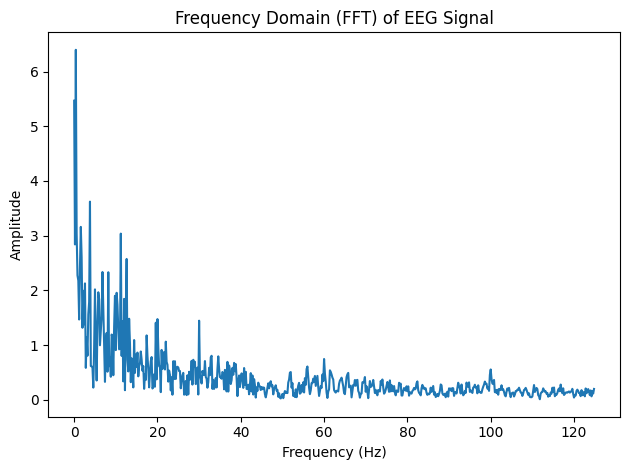

In [ ]:
ff = seg_orgin[:,2,ch_oz]
ff = ff.reshape(1250, order = "F")
fft(ff)

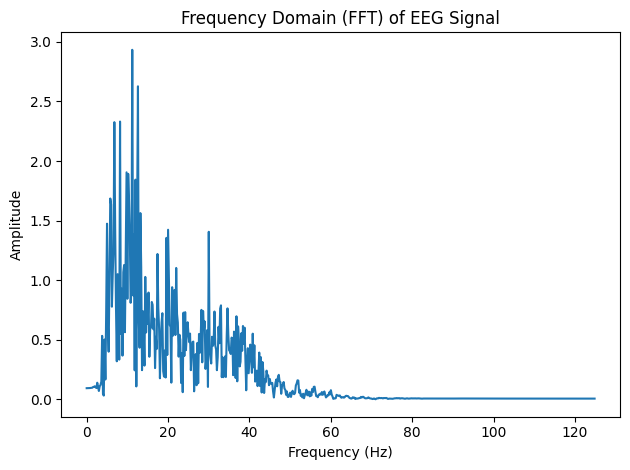

In [ ]:
ff = seg_bandpass[:,2,ch_oz]
ff = ff.reshape(1250, order = "F")
fft(ff)

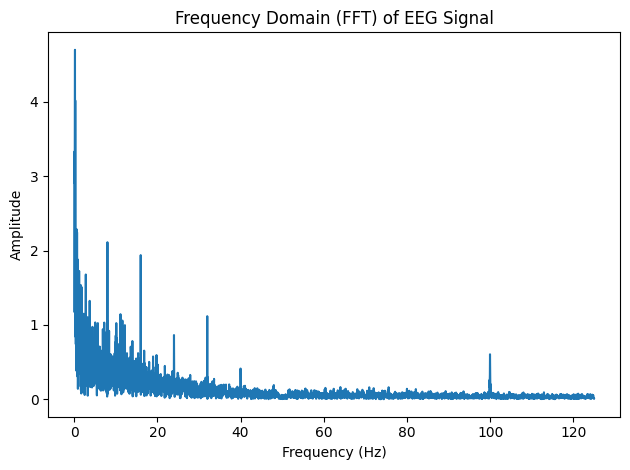

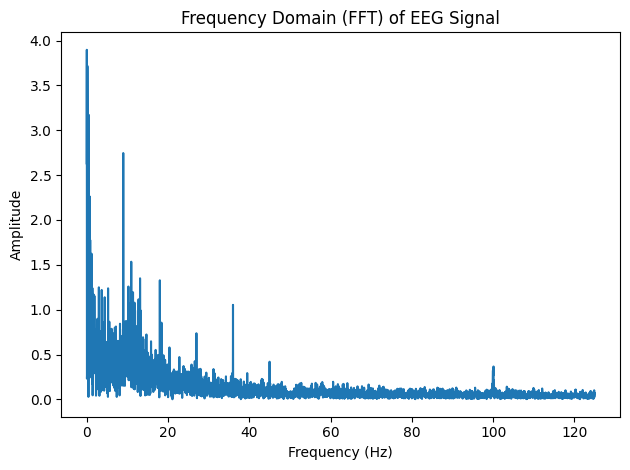

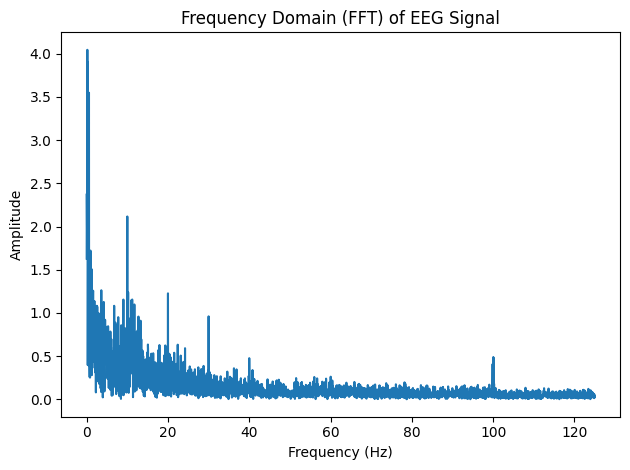

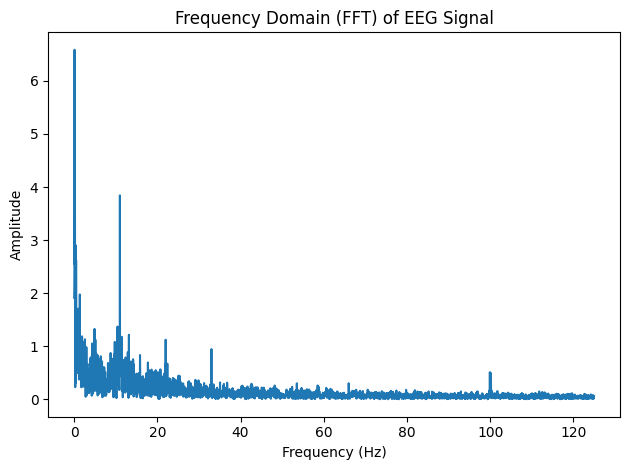

In [ ]:
# frequencies = [12, 8.57, 6.67, 5.45]  # Stimulation frequencies (Hz)
for i in range(4):
    f = seg_orgin[:,tr_Label[:]==i, ch_oz]
    f = f.reshape(7500, order = 'F')
    fft(f)

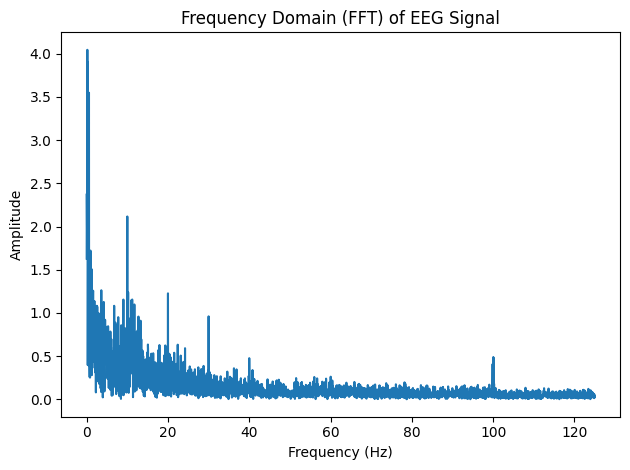

In [ ]:
f = seg_orgin[:,tr_Label[:]==2, ch_oz]
f = f.reshape(7500, order = 'F')
fft(f)

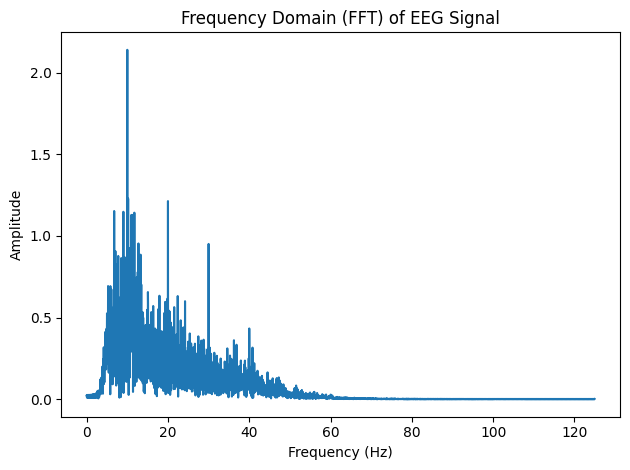

In [ ]:
f = seg_bandpass[:,tr_Label[:]==2, ch_oz]
f = f.reshape(7500, order = 'F')
fft(f)

In [ ]:
frequencies = [  8,   9,   10,   11,   12,   13,   14,   15,
               8.2, 9.2, 10.2, 11.2, 12.2, 13.2, 14.2, 15.2,
               8.4, 9.4, 10.4, 11.4, 12.4, 13.4, 14.4, 15.4,
               8.6, 9.6, 10.6, 11.6, 12.6, 13.6, 14.6, 15.6,
               8.8, 9.8, 10.8, 11.8, 12.8, 13.8, 14.8, 15.8]  # Stimulation frequencies (Hz)
# Generate reference signals
reference_signals = generate_reference_signals(fs, 1250, frequencies)

In [ ]:
def myCCA(dat, ref):
    # dat = (t, dim) -> (시간 샘플 수, EEG 채널 수)
    # ref = (t, dim) -> (시간 샘플 수, 참조 신호 수)
    L_size = np.size(ref, 0)

    # 1. 공분산 및 상호분산 행렬 계산
    R_xx = np.dot(dat.T, dat)   # EEG 채널 간의 자기상관 (62, 62)
    R_yy = np.dot(ref.T, ref)   # 참조 신호 간의 자기상관 (6, 6)

    R_xy = np.dot(dat.T, ref)   # EEG와 참조 신호 간의 상호상관 (62, 6)
    R_yx = np.dot(ref.T, dat)   # 참조 신호와 EEG 간의 상호상관 (6, 62)

    # 2. 행렬 연산을 위한 도구 설정
    mul = np.matmul             # 행렬 곱셈 함수
    inv = np.linalg.pinv        # 역행렬(의사 역행렬) 함수

    # 3. 고유값 문제를 해결하기 위한 행렬 R_x, R_y 구성
    # 공식: inv(R_xx) * R_xy * inv(R_yy) * R_yx
    R_x = mul(mul(mul(inv(R_xx), R_xy), inv(R_yy)), R_yx)

    # 공식: inv(R_yy) * R_yx * inv(R_xx) * R_xy
    R_y = mul(mul(mul(inv(R_yy), R_yx), inv(R_xx)), R_xy)

    # 4. EEG 가중치 벡터 'a' 추출
    L, C = np.linalg.eig(R_x)   # 고유값(L)과 고유벡터(C) 계산
    idx = np.argsort(L)[::-1]   # 고유값이 큰 순서(내림차순)로 정렬 인덱스 생성
    L = L[idx]                  # 고유값 정렬
    C = C[:, idx]               # 고유벡터 정렬
    a = np.real(C[:, 0])        # 가장 큰 상관성을 가지는 첫 번째 고유벡터 선택

    # 5. 참조 신호 가중치 벡터 'b' 추출
    L, C = np.linalg.eig(R_y)   # 고유값과 고유벡터 계산
    idx = np.argsort(L)[::-1]   # 내림차순 정렬
    L = L[idx]
    C = C[:, idx]
    b = np.real(C[:, 0])        # 가장 큰 상관성을 가지는 첫 번째 고유벡터 선택

    # 6. 정준 변수 생성 및 상관계수(r) 계산
    cca_eeg = np.dot(dat, a)    # EEG 데이터를 가중치 a로 투영 (Canonical Variable)
    cca_ref = np.dot(ref, b)    # 참조 신호를 가중치 b로 투영 (Canonical Variable)

    # 두 투영된 신호 사이의 상관계수를 계산 (Pearson correlation)
    r = np.corrcoef(cca_eeg.T, cca_ref.T)[0, 1]

    return a, b, r

In [ ]:
reference_signals[0].shape

(1250, 6)

In [ ]:
ch_idx = list(range(64))
ch_idx.remove(1) # FPZ
ch_idx.remove(9) # FZ

out2 = []
for i in range(240):
    eeg_data = seg_orgin[:,i,ch_idx]
    correlations = []
    for ref in reference_signals:
        [a, b, r] = myCCA(eeg_data, ref)
        correlations.append(np.abs(r))
        print(r)

    # Find the frequency with the highest correlation
    max_corr_freq = frequencies[np.argmax(correlations)]
    out2.append(np.argmax(correlations))

# Y = np.argmax(tr_Label, axis = 0)
Y = tr_Label
np.sum(Y==out2) / len(out2)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
0.3808061978973005
0.4130190809437598
-0.43794376305283345
0.5377926254651564
0.43168853038300925
0.3406562689582601
0.3967261507284345
0.36018440359927434
0.36628460330055623
-0.43522075847050024
0.4502485592367311
0.5147249503103888
0.4166369585538984
-0.3322041111364012
-0.3414439158300142
-0.3218796496629383
-0.41573893360918135
0.40251748433791207
0.5528653485120252
-0.6472111897867457
0.44613599975323265
-0.39300885928015156
-0.31502717155696575
-0.2994484057323047
-0.34270803774098246
0.3959036835181852
-0.46434377439829705
-0.6162764780970582
0.4292120903492969
-0.3676266049078379
0.3219241026615893
0.31989391851885296
-0.41671322298978924
0.462334026995234
0.5449155169180656
0.7529213299834014
0.4440384175876089
0.296015210068441
0.30917223986542486
0.3265380350916931
0.4471110255600141
0.404664670959401
0.5101321341457414
0.5488981074998304
0.5118132089459794
-0.3527645542899902
-0.3326341411717714
-0.3345082985645178
0.4463162380019947
0.4

np.float64(0.8916666666666667)

In [ ]:
ch_idx = [ch_oz-1, ch_oz, ch_oz+1]

out2 = []

for i in range(240):
    eeg_data = seg_bandpass[:,i,ch_idx]
    correlations = []
    for ref in reference_signals:
        [a, b, r] = myCCA(eeg_data, ref)
        correlations.append(np.abs(r))

    # Find the frequency with the highest correlation
    max_corr_freq = frequencies[np.argmax(correlations)]
    out2.append(np.argmax(correlations))

# Y = np.argmax(tr_Label, axis = 0)
Y = tr_Label
np.sum(Y==out2) / len(out2)

np.float64(0.9125)